# Introduction to iEEG Sleep Data Analysis with MNE Python

This notebook will guide you through the basics of analyzing intracranial EEG (iEEG) sleep data.
You will learn how to:

1. Download iEEG data from OpenNeuro using Datalad
2. Load and explore recording properties
3. Understand EEG frequency bands and filters
4. Implement automatic sleep stage detection based on EEG bands

Note: This tutorial uses data from OpenNeuro and assumes you're running in Google Colab with Google Drive mounted.

## Downloading iEEG data and doing first exploration

Let's start with comparing scalp with incranial EEG.

**Intracranial EEG (iEEG)** records electrical activity from electrodes placed
*inside* the skull - directly on or inside brain tissue. This is different from
the scalp EEG cap you may have seen in pictures.

| Feature | Scalp EEG | iEEG |
|---|---|---|
| Electrode position | On the scalp | Inside the skull |
| Signal quality | Blurred by skull & skin | High-fidelity, local |
| Typical use | Routine clinical/research | Pre-surgical epilepsy evaluation |
| Spatial resolution | Low (~cm) | High (~mm) |
| Frequency range | Up to ~70 Hz (usable) | Up to ~1000 Hz |

> **Why does this matter?** The skull acts like a low-pass filter -- it smears
> signals from many sources together. iEEG lets us listen to very local neural
> populations with much less noise.

Let's load one exemplar iEEG data using Python packages:

In [ ]:
# Install packages and, specifically, git-annex to download the data from OpenNeuro

!apt-get install -y netbase
!pip install datalad datalad-installer mne mne-bids
!datalad-installer git-annex -m datalad/git-annex:release

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  netbase
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
1 not fully installed or removed.
Need to get 12.9 kB of archives.
After this operation, 42.0 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 netbase all 6.3 [12.9 kB]
Fetched 12.9 kB in 0s (46.6 kB/s)
Selecting previously unselected package netbase.
(Reading database ... 120826 files and directories currently installed.)
Preparing to unpack .../archives/netbase_6.3_all.deb ...
Unpacking netbase (6.3) ...
Setting up netbase (6.3) ...
Setting up git-annex-standalone (10.20260316-1~ndall+1) ...
2026-04-17T14:32:16+0000 [INFO    ] datalad_installer: Writing environment modifications to /tmp/dl-env-8n05dgqd.sh
2026-04-17T14:32:16+0000 [INFO    ] datalad_installer: Installing git-annex via datalad/git-annex:release
2026-04-17T14:

In [ ]:
import datalad.api as dl
import mne
import numpy as np
import matplotlib.pyplot as plt

from mne_bids import BIDSPath, read_raw_bids
from pathlib import Path


homepath = '/content/drive/MyDrive/iEEG_course_UCL' # change the path to yours
bids_root = f'{homepath}/ds003498'

# Clone the whole tree in seconds (just metadata of the dataset, ~MB)
# If you wanna check the dataset by youtself, all uinfo is available at OpenNeuro: https://openneuro.org/datasets/ds003498
ds = dl.clone('https://github.com/OpenNeuroDatasets/ds003498.git', path=bids_root)

# Download data for sub-02 and sub-03 (we will use that one later)
ds.get(['sub-02/', 'sub-03/'])

INFO:datalad:Clear progress bars
INFO:datalad:Refresh progress bars


action summary:
  get (notneeded: 2)


[{'action': 'get',
  'path': '/content/drive/MyDrive/iEEG_course_UCL/ds003498/sub-02',
  'type': 'directory',
  'refds': '/content/drive/MyDrive/iEEG_course_UCL/ds003498',
  'status': 'notneeded',
  'message': ('nothing to get from %s',
   '/content/drive/MyDrive/iEEG_course_UCL/ds003498/sub-02')},
 {'action': 'get',
  'path': '/content/drive/MyDrive/iEEG_course_UCL/ds003498/sub-03',
  'type': 'directory',
  'refds': '/content/drive/MyDrive/iEEG_course_UCL/ds003498',
  'status': 'notneeded',
  'message': ('nothing to get from %s',
   '/content/drive/MyDrive/iEEG_course_UCL/ds003498/sub-03')}]

In [ ]:
# Load data

vhdr_path = Path(bids_root) / "sub-02" / "ses-interictalsleep" / "ieeg" / "sub-02_ses-interictalsleep_run-01_ieeg.vhdr"

raw = mne.io.read_raw_brainvision(vhdr_path, verbose=True, preload=True)

Extracting parameters from /content/drive/MyDrive/iEEG_course_UCL/ds003498/sub-02/ses-interictalsleep/ieeg/sub-02_ses-interictalsleep_run-01_ieeg.vhdr...
Setting channel info structure...
Reading 0 ... 599999  =      0.000 ...   300.000 secs...


The info structure contains important metadata:

* **Number of channels**: How many electrodes were recording
* **Sampling frequency (sfreq)**: How many data points per second (typically 512 Hz or higher for iEEG)
* **Duration**: Total recording length in seconds
* **Channel names and types**: Identifies each electrode location

Let's examine these properties more clearly:

In [ ]:
# Key recording properties

n_channels = len(raw.ch_names)
sampling_freq = raw.info['sfreq']
duration = raw.times[-1]

print(f"Number of channels: {n_channels}")
print(f"Sampling frequency: {sampling_freq} Hz")
print(f"Duration: {duration:.2f} seconds ({duration/60:.2f} minutes)")
print(f"\nChannel names: {raw.ch_names}")

Number of channels: 64
Sampling frequency: 2000.0 Hz
Duration: 300.00 seconds (5.00 minutes)

Channel names: ['AHL1', 'AHL2', 'AHL3', 'AHL4', 'AHL5', 'AHL6', 'AHL7', 'AHL8', 'AHR1', 'AHR2', 'AHR3', 'AHR4', 'AHR5', 'AHR6', 'AHR7', 'AHR8', 'AL1', 'AL2', 'AL3', 'AL4', 'AL5', 'AL6', 'AL7', 'AL8', 'AR1', 'AR2', 'AR3', 'AR4', 'AR5', 'AR6', 'AR7', 'AR8', 'ECL1', 'ECL2', 'ECL3', 'ECL4', 'ECL5', 'ECL6', 'ECL7', 'ECL8', 'ECR1', 'ECR2', 'ECR3', 'ECR4', 'ECR5', 'ECR6', 'ECR7', 'ECR8', 'PHL1', 'PHL2', 'PHL3', 'PHL4', 'PHL5', 'PHL6', 'PHL7', 'PHL8', 'PHR1', 'PHR2', 'PHR3', 'PHR4', 'PHR5', 'PHR6', 'PHR7', 'PHR8']


The data has 64 channels and the length is 5 minutes with 2000 data points per second.

Let's plot a short segment of the raw data to see what iEEG looks like.

Using matplotlib as 2D backend.


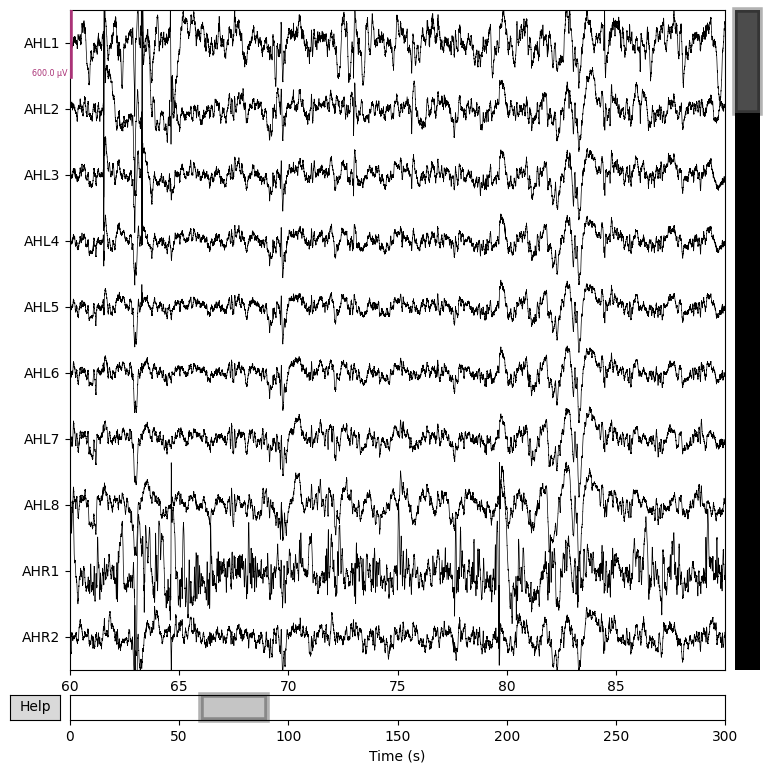

The plot shows voltage (microvolts) over time for the first 3 channels.


In [ ]:
# Plot 30 seconds of data starting at 60 seconds

raw_copy = raw.copy()
raw_copy.set_annotations(None) # remove annotations temporarily for plotting

raw_copy.plot(start=60, duration=30, n_channels=10, scalings=dict(eeg=300e-6), title='iEEG Signal')
print("The plot shows voltage (microvolts) over time for the first 3 channels.")

This is actual electrical activity from inside a human brain, recorded by electrodes placed directly inside the brain of a patient. Each trace represents one electrode, and every wiggle is thousands of neurons firing in synchrony.

Let's have a look at the **Power Spectrum Density (PSD)**. PSD describes how the power (energy) of a neural signal is distributed across different frequencies. Instead of looking at the signal over time, PSD shows which frequencies dominate the activity.

In iEEG, this matters because brain activity is strongly frequency-specific. Different frequency bands (e.g., theta, alpha, gamma) are linked to distinct neural processes like memory, attention, or local neuronal firing. PSD lets you quantify these components objectively.

It is important for iEEG because it helps:

*   identify **neural rhythms** and their changes across conditions
*   detect **pathological** activity (e.g., abnormal high-frequency power in epilepsy)
*   compare brain states (rest vs task, different cognitive conditions)
*   **extract features** for analysis and machine learning

In short, PSD turns raw signals into interpretable frequency-based information, which is central to understanding iEEG data.

Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_23587/983361717.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = raw.compute_psd().plot(picks='data', exclude='bads', amplitude=False)


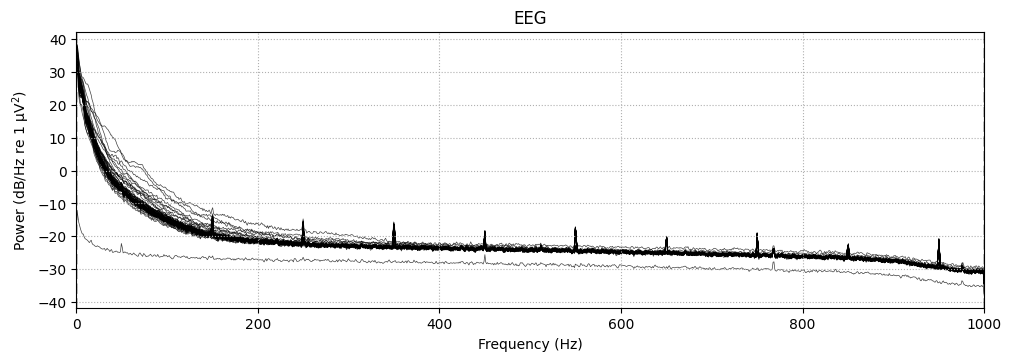

In [ ]:
# Compute and plot Power Spectrum Density (PSD)

fig = raw.compute_psd().plot(picks='data', exclude='bads', amplitude=False)

This plot reveals several fascinating features of brain electrical activity:

**The 1/f Pattern (Pink Noise)**
Notice how power decreases dramatically as frequency increases - this is the characteristic "1/f" or pink noise pattern of brain activity. The brain produces much stronger low-frequency oscillations than high-frequency ones. This isn't random; it reflects the fundamental organization of neural networks where large populations of neurons synchronize at slower rhythms.

**The Sharp Peaks Around 150 Hz and Harmonics**
See those tall, narrow spikes at regular intervals (around 250, 350 Hz, etc.)? These are **electrical line noise** - artifacts from the power grid in the recording environment. In Europe, mains electricity runs at 50 Hz, and you're seeing the fundamental frequency plus its harmonics (multiples). This is normal in EEG/iEEG recordings and would typically be filtered out for analysis. See the figure with different X-axis for better visualisation.

**Why the Y-axis is Negative**
Power is plotted in decibels (dB), which uses a logarithmic scale. The negative values don't mean "negative power" - they indicate power levels relative to a reference. What matters is the relative differences between frequencies, not the absolute numbers.

**The Low-Frequency Dominance**
The highest power is concentrated below 10 Hz - the delta and theta ranges. This makes sense for sleep data, where slow oscillations dominate. During deep sleep, you'd see even more pronounced power in the 0.5-4 Hz delta band.

**Multiple Overlapping Lines**
Each line represents a different electrode. The fact that they mostly overlap shows relatively consistent spectral properties across recording sites, though some channels show slightly different profiles - possibly due to their anatomical location or local neural activity.


Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_23587/57707189.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig_fmax = raw.compute_psd(fmax=300).plot(picks='data', exclude='bads', amplitude=False)


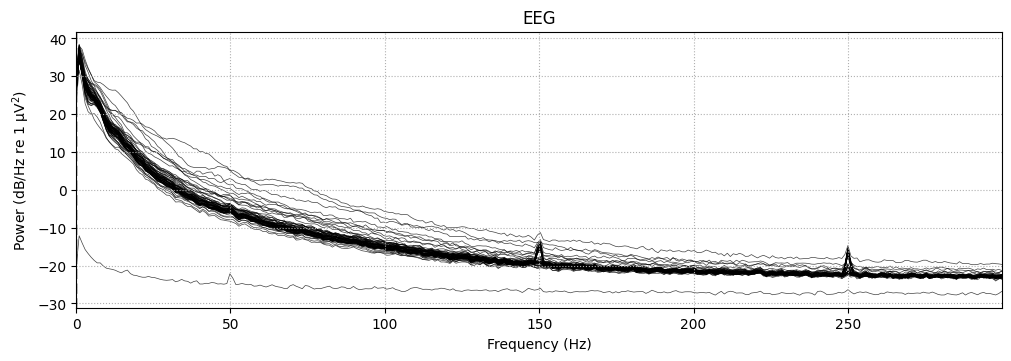

In [ ]:
# Compute and plot Power Spectrum Density (PSD)

fig_fmax = raw.compute_psd(fmax=300).plot(picks='data', exclude='bads', amplitude=False)

As you can see in the figure above, the signal has strong "peaks" around 150 and 250 Hz. A small peak even around 50 Hz in one channel, but the 50 and 100 Hz peaks were removed during data acquisition or preprocessing - thats why we dont see them right now.

## EEG frequency bands

To better understand what we're seeing in the PSD, it helps to know that neuroscientists have identified distinct frequency bands in brain electrical activity, each associated with different cognitive and physiological states.

Rather than treating the spectrum as a continuous blur, we carve it into named ranges.

***Standard EEG Frequency Bands***

**Delta (0.5-4 Hz)**
- Dominant during deep sleep (N3)
- High amplitude, slow waves
- Associated with restorative sleep processes

**Theta (4-8 Hz)**
- Present during drowsiness and light sleep (N1)
- Prominent in REM sleep
- Related to memory consolidation

**Alpha (8-12 Hz)**
- Characteristic of relaxed wakefulness with eyes closed
- Decreases during sleep onset
- Posterior dominant rhythm

**Beta (13-30 Hz)**
- Active thinking and alertness
- Low during sleep
- Increases during wake and REM

**Gamma (>30 Hz)**
- High-level cognitive processing
- Present during conscious awareness
- Less relevant for basic sleep staging



If we want to extract specific bands from our iEEG signal we can apply filters.

Filters are tools used to selectively keep or remove specific frequency components of a signal. They shape the signal by defining which frequencies are preserved and which are reduced.

*Common types of filters:*
*   **Low-pass filter** keeps slow frequencies, removes fast activity (e.g., high-frequency noise)
*   **High-pass filter** removes slow drifts, keeps faster neural activity
*   **Band-pass filter** keeps only a specific frequency range (e.g., theta, gamma)
*   **Notch filter** removes a very narrow frequency band, typically 50/60 Hz line noise

Let's run the code below to see how different filters affect the iEEG signal

In [ ]:
# pick channels
# define t

good_channels = [ch for ch in raw.ch_names if ch not in raw.info['bads']]
ch_name = good_channels[0]   # change to e.g. 'LA1' if you prefer
T_START, T_END = 60, 70      # seconds into the recording

fs = raw.info['sfreq']

def get_uv(raw_obj):
    """Extract the chosen channel as a 1-D µV array for the time window."""
    data = raw_obj.get_data(picks=[ch_name], tmin=T_START, tmax=T_END)[0]
    return data * 1e6  # V → µV

t = np.linspace(0, T_END - T_START,
                int((T_END - T_START) * fs), endpoint=False)

print(f"Channel : {ch_name}  |  Window : {T_START}–{T_END} s  |  FS : {fs} Hz")

Channel : AHL1  |  Window : 60–70 s  |  FS : 2000.0 Hz


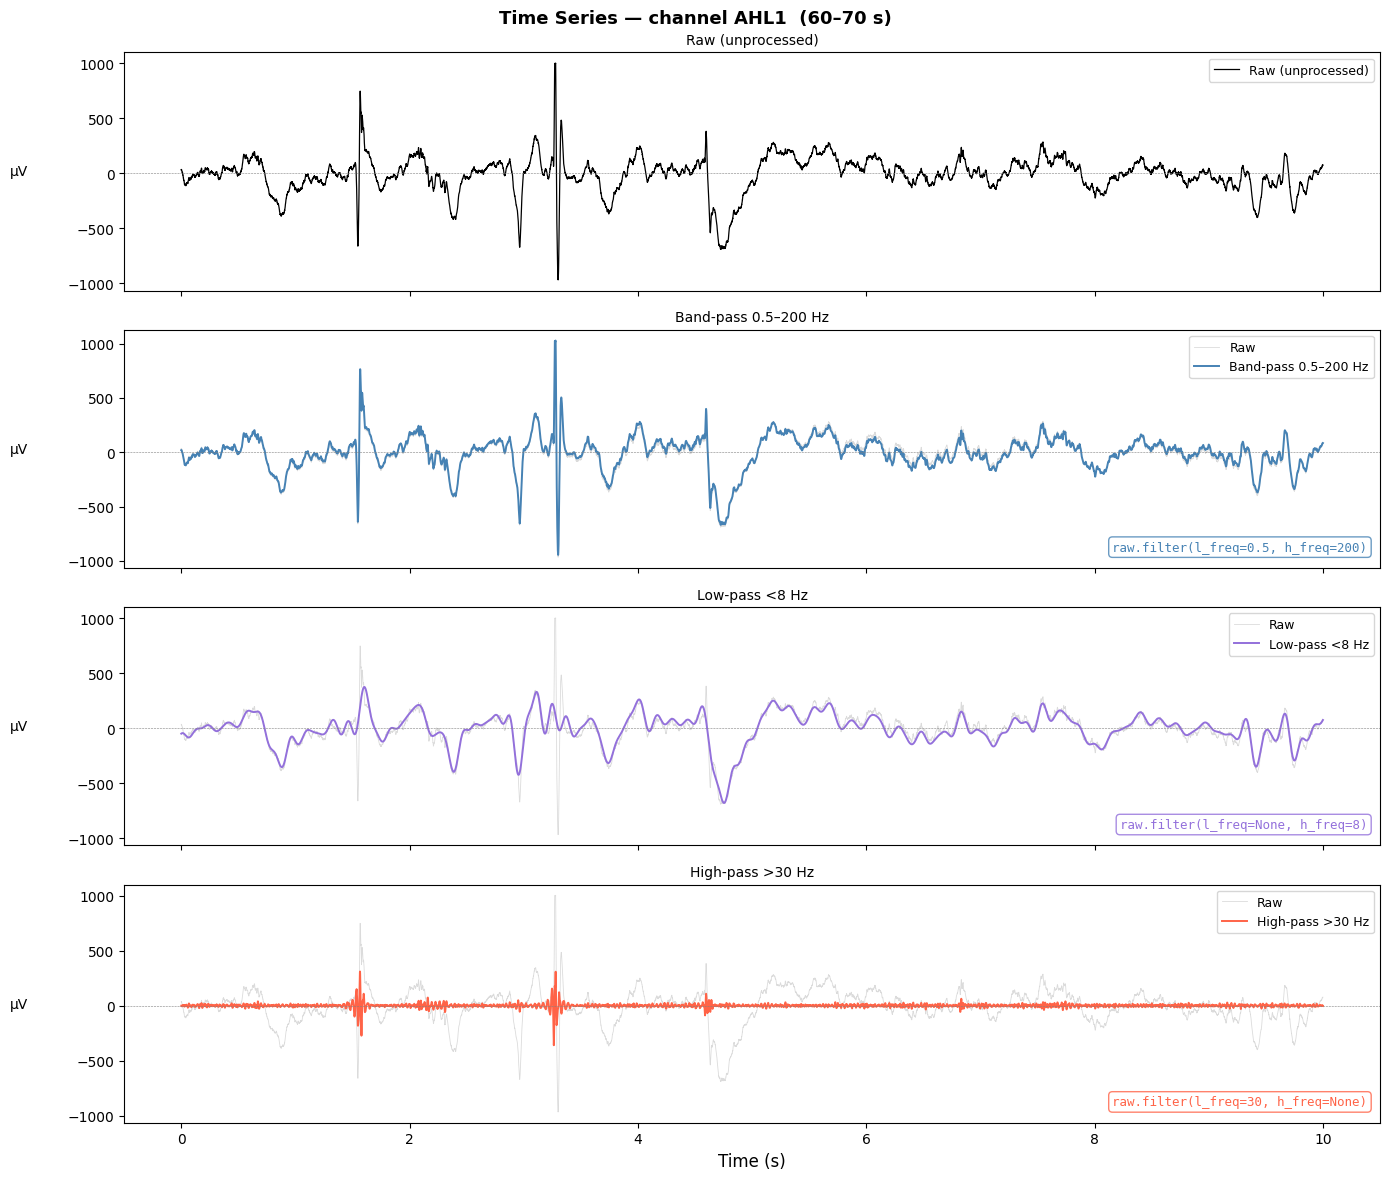

In [ ]:
# apply different filters (band-pass, low-pass, high-pass)
raw_bp   = raw.copy().filter(l_freq=0.5, h_freq=200.0, method='fir', verbose=False)
raw_slow = raw_bp.copy().filter(l_freq=None, h_freq=8.0, verbose=False)   # low-pass
raw_fast = raw_bp.copy().filter(l_freq=30.0, h_freq=None, verbose=False)  # high-pass

sig_raw  = get_uv(raw)
sig_bp   = get_uv(raw_bp)
sig_slow = get_uv(raw_slow)
sig_fast = get_uv(raw_fast)


# plot
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'Time Series — channel {ch_name}  ({T_START}–{T_END} s)',
             fontsize=13, fontweight='bold')

panels = [
    (sig_raw,  'Raw (unprocessed)',     'black',        None),
    (sig_bp,   'Band-pass 0.5–200 Hz',  'steelblue',    'raw.filter(l_freq=0.5, h_freq=200)'),
    (sig_slow, 'Low-pass <8 Hz',        'mediumpurple', 'raw.filter(l_freq=None, h_freq=8)'),
    (sig_fast, 'High-pass >30 Hz',      'tomato',       'raw.filter(l_freq=30, h_freq=None)'),
]

for ax, (sig, title, color, mne_call) in zip(axes, panels):
    if color != 'black':
        ax.plot(t, sig_raw, color='lightgray', lw=0.6, alpha=0.8, label='Raw')
    ax.plot(t, sig, color=color, lw=0.9 if color == 'black' else 1.4,
            label=title)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('µV', rotation=0, labelpad=35, va='center')
    ax.axhline(0, color='gray', lw=0.4, ls='--')
    if mne_call:
        ax.text(0.99, 0.06, mne_call, transform=ax.transAxes,
                fontsize=9, color=color, ha='right', va='bottom',
                family='monospace',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          alpha=0.8, ec=color))

axes[-1].set_xlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.show()

**Reading the figure top to bottom**

The four panels show the exact same 10 seconds of iEEG, just viewed through different "windows." Each filter lets certain frequencies through and blocks others.

**Raw (black):** This is the unprocessed signal straight from the electrode. You can see it is dominated by large, slow swings (the broad up-and-down waves) but also contains sharp transient spikes. The overall amplitude reaches ±1000 µV.

**Band-pass 0.5-200 Hz (blue):** Visually this looks almost identical to raw, which is the point. Band-passing between 0.5 and 200 Hz is just housekeeping. It removes the very slow DC drift below 0.5 Hz and any extreme high-frequency noise above 200 Hz, but leaves all the neurologically meaningful content intact. It doesn't change the shape of the signal much since the most of the signal is inside this band.

**Low-pass <8 Hz (purple):** Now things look dramatically different. All the fast, jagged fluctuations are gone and what remains are only the slow, smooth undulations. These are your **delta and theta waves**, the dominant rhythms of sleep. Notice the amplitude is still large (hundreds of µV). Slow waves carry a lot of power, which is exactly what the PSD showed earlier with its steep 1/f slope. The sharp spikes from the raw signal have almost completely disappeared because spikes are broadband events: they need high frequencies to look sharp, and we have removed those.

**High-pass >30 Hz (red):** This is the inverse story. By removing everything below 30 Hz, the slow waves vanish and you are left with tiny, rapid oscillations around the zero line. The amplitude is now only a few tens of µV, a reminder that high-frequency activity carries very little power compared to slow waves. The bursts of fast activity correspond to the same spike events visible in the raw signal. Spikes have rich high-frequency content, which is why they still show up here even though the slow wave underneath them has been stripped away.

**The key intuition:** A raw EEG/iEEG signal is a mixture of many rhythms happening simultaneously. Filters do not change the signal, they selectively reveal different components that were always there, layered on top of each other.

Let's do the same thing and look at PSD profiles!

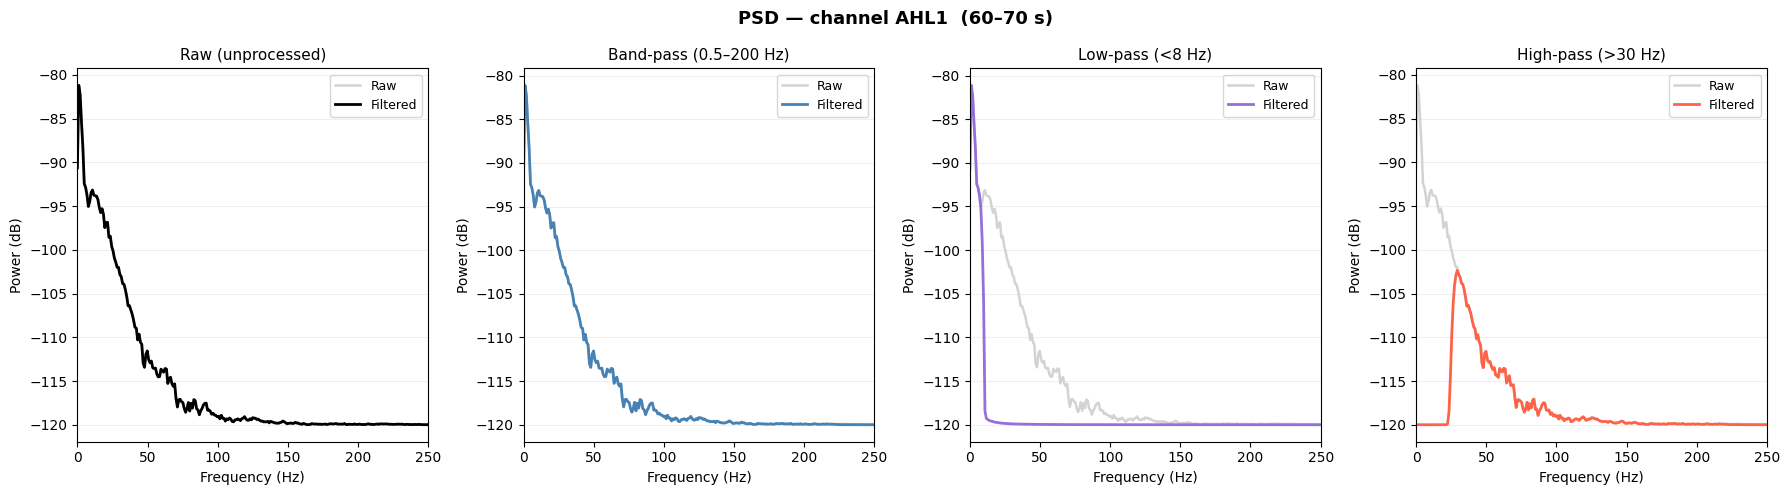

In [ ]:
# plot

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'PSD — channel {ch_name}  ({T_START}–{T_END} s)',
             fontsize=13, fontweight='bold')

def plot_psd_comparison(ax, raw_filtered, color, title):
    psd_raw  = raw.copy().crop(T_START, T_END).compute_psd(fmax=250, verbose=False)
    psd_filt = raw_filtered.copy().crop(T_START, T_END).compute_psd(fmax=250, verbose=False)

    f      = psd_raw.freqs
    p_raw  = 10 * np.log10(psd_raw.get_data(picks=[ch_name]).mean(axis=0)  + 1e-12)
    p_filt = 10 * np.log10(psd_filt.get_data(picks=[ch_name]).mean(axis=0) + 1e-12)

    ax.plot(f, p_raw,  color='lightgray', lw=1.8, label='Raw')
    ax.plot(f, p_filt, color=color,       lw=2.0, label='Filtered')

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (dB)')
    ax.set_xlim(0, 250)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)


plot_psd_comparison(axes[0], raw, 'black', 'Raw (unprocessed)')
plot_psd_comparison(axes[1], raw_bp, 'steelblue', 'Band-pass (0.5–200 Hz)')
plot_psd_comparison(axes[2], raw_slow, 'mediumpurple', 'Low-pass (<8 Hz)')
plot_psd_comparison(axes[3], raw_fast, 'tomato', 'High-pass (>30 Hz)')

plt.tight_layout()
plt.show()

**Raw (black)**: The classic 1/f shape where power is highest at low frequencies and falls off steeply as frequency increases. This is your baseline reference for all other panels.

**Band-pass 0.5-200 Hz (blue)**: Nearly identical to raw across most of the range, confirming that band-passing preserves the neurological signal. Since we took a wide range (0.5-200Hz), not many changes can be seen.

**Low-pass < 8 Hz (purple)**: The filtered curve follows the raw almost exactly up to about 8 Hz, then drops sharply to the noise floor and stays flat for the remaining part of the plot. Everything to the right of that cliff is gone.

**High-pass > 30 Hz (red)**: The mirror image of the low-pass. Power below 30 Hz is completely removed and what remains is a small shoulder of activity between roughly 30 and 80 Hz before it fades into the noise floor. Notice how low the absolute power is compared to raw. This confirms what the time series showed: high-frequency activity exists in this signal but carries very little energy relative to the slow waves.

Now, when we understand the filtering of iEEG signal, we can extract EEG bands (delta, theta, alpha, beta) from our signal and look at them!

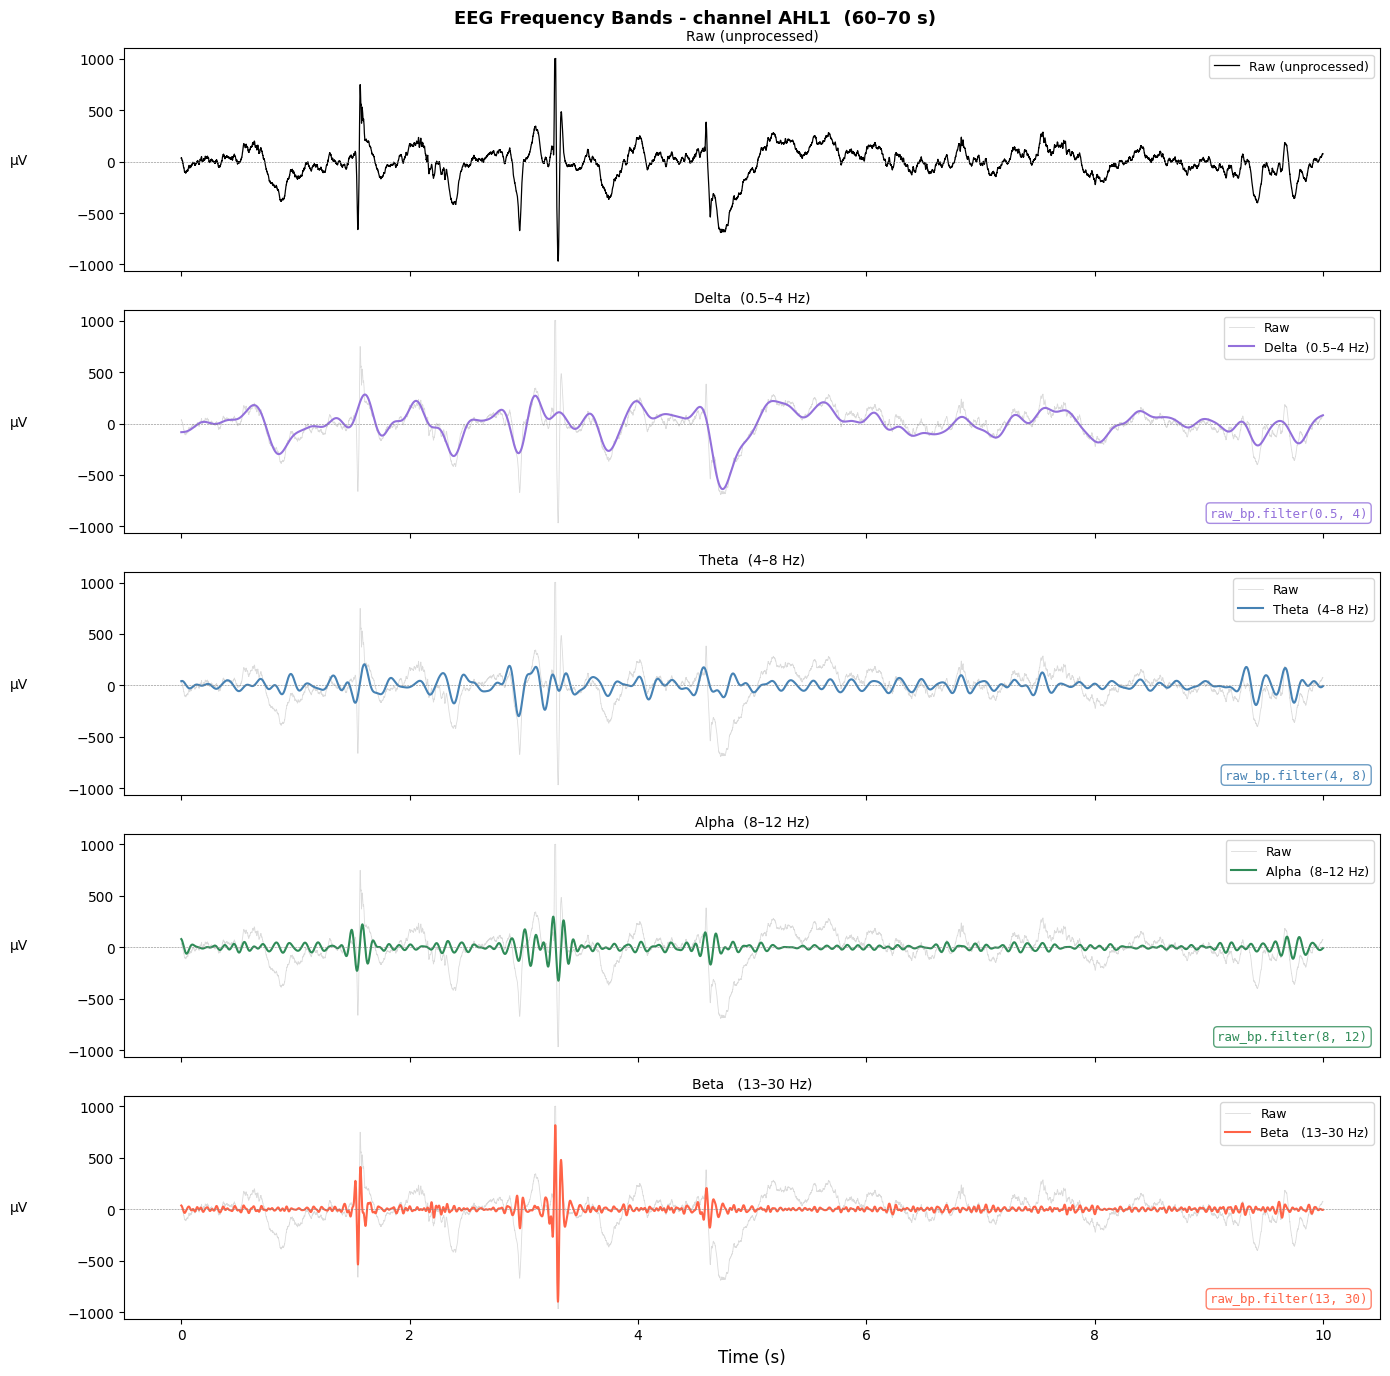

In [ ]:
# Extract EEG frequency bands

raw_delta = raw_bp.copy().filter(l_freq=0.5, h_freq=4.0,  verbose=False)
raw_theta = raw_bp.copy().filter(l_freq=4.0, h_freq=8.0,  verbose=False)
raw_alpha = raw_bp.copy().filter(l_freq=8.0, h_freq=12.0, verbose=False)
raw_beta  = raw_bp.copy().filter(l_freq=13.0, h_freq=30.0, verbose=False)

sig_delta = get_uv(raw_delta)
sig_theta = get_uv(raw_theta)
sig_alpha = get_uv(raw_alpha)
sig_beta  = get_uv(raw_beta)

# plot them
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
fig.suptitle(f'EEG Frequency Bands - channel {ch_name}  ({T_START}–{T_END} s)',
             fontsize=13, fontweight='bold')

bands = [
    (sig_raw,   'Raw (unprocessed)',        'black',        None,           None),
    (sig_delta, 'Delta  (0.5–4 Hz)',        'mediumpurple', '0.5–4 Hz',     'raw_bp.filter(0.5, 4)'),
    (sig_theta, 'Theta  (4–8 Hz)',          'steelblue',    '4–8 Hz',       'raw_bp.filter(4, 8)'),
    (sig_alpha, 'Alpha  (8–12 Hz)',         'seagreen',     '8–12 Hz',      'raw_bp.filter(8, 12)'),
    (sig_beta,  'Beta   (13–30 Hz)',        'tomato',       '13–30 Hz',     'raw_bp.filter(13, 30)'),
]

for ax, (sig, title, color, band_label, mne_call) in zip(axes, bands):
    if color != 'black':
        ax.plot(t, sig_raw, color='lightgray', lw=0.6, alpha=0.8, label='Raw')
    ax.plot(t, sig, color=color, lw=0.9 if color == 'black' else 1.5,
            label=title)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('µV', rotation=0, labelpad=35, va='center')
    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.legend(fontsize=9, loc='upper right')
    if mne_call:
        ax.text(0.99, 0.06, mne_call, transform=ax.transAxes,
                fontsize=9, color=color, ha='right', va='bottom',
                family='monospace',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          alpha=0.8, ec=color))

axes[-1].set_xlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.show()

## Summary


**What is iEEG and why does it matter?**
Unlike scalp EEG, iEEG records directly from inside the skull, millimetres from the neurons of interest. This gives it far higher spatial resolution (~mm vs ~cm), a much wider usable frequency range (up to ~1000 Hz vs ~70 Hz), and far less signal blurring from the skull and scalp. The trade-off is that iEEG is only available in clinical settings, most commonly from patients undergoing pre-surgical evaluation for epilepsy.
Loading and exploring data
We used MNE-Python to load a BrainVision recording (.vhdr) from the OpenNeuro dataset. The raw.info structure gives us the essential metadata: number of channels, sampling frequency, and recording duration. Plotting a short segment gives an immediate visual sense of the signal: large slow waves visible to the eye, and rapid small-amplitude activity riding on top.
Power Spectral Density (PSD)
PSD converts the time-domain signal into the frequency domain, showing how much power each frequency contributes. Key features we saw:

**The 1/f slope**: power falls steeply with frequency, a universal property of brain signals
Line noise peaks at 50 Hz harmonics (150, 250 Hz...) from the power grid, which need to be filtered out before analysis
Low-frequency dominance below 10 Hz, consistent with sleep data where delta and theta rhythms prevail

**Frequency bands and filters**
Neuroscientists divide the spectrum into named bands: delta (0.5-4 Hz), theta (4-8 Hz), alpha (8-12 Hz), beta (13-30 Hz), and gamma (>30 Hz), each linked to distinct brain states. Filters let us isolate these bands. A low-pass filter reveals only the slow, high-amplitude sleep waves; a high-pass filter strips those away and leaves only fast, low-amplitude activity; a notch filter removes line noise at a single narrow frequency. The key intuition: filtering does not change the signal, it selectively reveals components that were always there, layered on top of each other.

**What comes next**
In Notebook 2 we will deal with a practical reality of iEEG: not all of what we recorded is genuine neural signal. Before any analysis, we need to identify and remove artifacts, including noisy channels, movement transients, and line noise, to ensure our results reflect brain activity and not recording problems.